In [1]:
import sys
import numpy as np
import pandas as pd
import os
import time
import json
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.ga_engine import GAEngine,run_ga_engine
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
current_dir = os.getcwd()
data_dir = os.path.join(os.path.dirname(current_dir), 'data', 'processed')

csv_file_path = os.path.join(data_dir, "cleaned_delivery_orders.csv")
npz_file_path = os.path.join(data_dir, "vrp_mathematical_matrices.npz")

matrices = np.load(npz_file_path, allow_pickle=True)
df = pd.read_csv(csv_file_path)
print("Available keys in archive:", matrices.files)

n_nodes = 200
population_size = 100
mx_generations = 50
mutation_rate = 0.05

Available keys in archive: ['cargo_weights', 'order_values', 'service_times', 'window_starts', 'window_ends', 'distance_matrix_km', 'time_cost_matrix', 'vehicle_capacities', 'vehicle_shifts_min']


In [3]:
# Instantiate your engine with the parameters
n_nodes = len(matrices['cargo_weights'])
# n_nodes = 5
vehicle_capacities = matrices['vehicle_capacities'].tolist()
vehicle_shifts_min = matrices['vehicle_shifts_min'].tolist()
print(f"Fleet size: {len(vehicle_capacities)} vehicles | Capacities: {sorted(set(vehicle_capacities))} kg | Shifts: {sorted(set(vehicle_shifts_min))} min")


Fleet size: 20 vehicles | Capacities: [3000, 5000, 8000] kg | Shifts: [540, 660] min


In [4]:
# Main productive run

results = run_ga_engine(
    n_nodes = n_nodes,
    population_size = 100,
    penalty_value=10000,
    vehicle_capacity=vehicle_capacities, 
    vehicle_shifts_min=vehicle_shifts_min,
    matrices=matrices, 
    df=df, 
    mx_generations=500, 
    patience=20,
    mutation_rate=0.05, 
    crossover_rate=0.8, 
    seed=42
)

history = results['history']
best_routes = results['best_routes']
deferred_nodes = results['deferred_nodes']
execution_time = results['execution_time']


print(f"Algorithm completed at generation {results['generations_run']}. Best Fitness Score = {results['fitness_score']}. ")
print(f"Revenue achieved: {results['actual_revenue']} LKR. Deferred Orders: {len(results['deferred_nodes'])}.")
print(f"Execution time: {results['execution_time']:.2f} seconds.")

Algorithm completed at generation 222. Best Fitness Score = 1998400.0. 
Revenue achieved: 2098400.0 LKR. Deferred Orders: 134.
Execution time: 96.56 seconds.


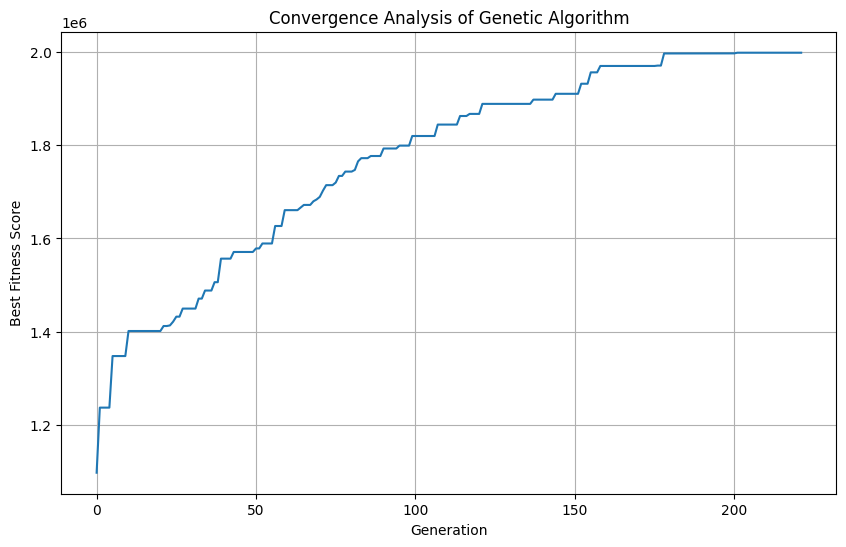

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(history)
plt.title('Convergence Analysis of Genetic Algorithm')
plt.xlabel('Generation')
plt.ylabel('Best Fitness Score')
plt.grid(True)
plt.show()

pop=50, mut_rate=0.01: fitness=1612900, revenue=1742900, time=8.7s
pop=50, mut_rate=0.05: fitness=1500800, revenue=1640800, time=7.1s
pop=50, mut_rate=0.1: fitness=1564750, revenue=1679950, time=11.4s
pop=100, mut_rate=0.01: fitness=1695800, revenue=1815800, time=20.0s
pop=100, mut_rate=0.05: fitness=1401600, revenue=1561600, time=9.1s
pop=100, mut_rate=0.1: fitness=1914800, revenue=1999400, time=27.5s
pop=200, mut_rate=0.01: fitness=1868900, revenue=1958900, time=47.4s
pop=200, mut_rate=0.05: fitness=2093600, revenue=2163600, time=47.1s
pop=200, mut_rate=0.1: fitness=1902900, revenue=2002900, time=47.0s


,population,mutation_rate,best_fitness,Score,execution_time
0,50,0.01,1612900.0,1742900.0,8.677025
1,50,0.05,1500800.0,1640800.0,7.115665
2,50,0.10,1564750.0,1679950.0,11.420457
3,100,0.01,1695800.0,1815800.0,19.979817
4,100,0.05,1401600.0,1561600.0,9.082339
5,100,0.10,1914800.0,1999400.0,27.454431
6,200,0.01,1868900.0,1958900.0,47.379593
7,200,0.05,2093600.0,2163600.0,47.094366
8,200,0.10,1902900.0,2002900.0,46.986168


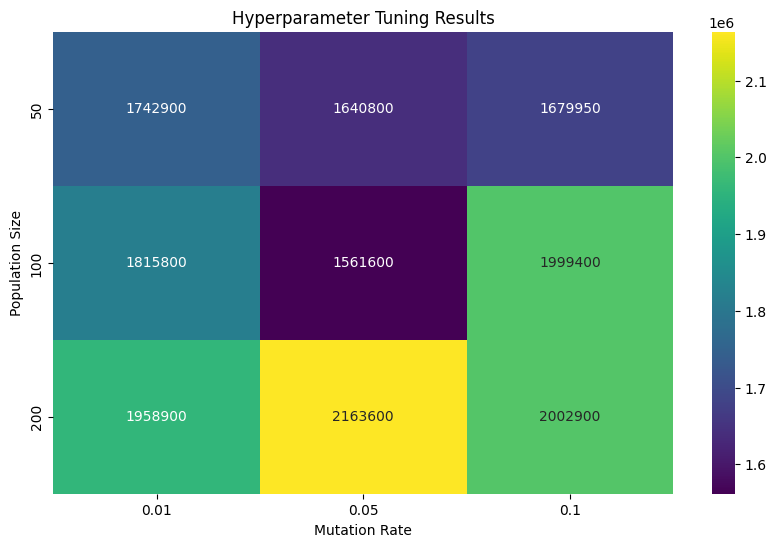

In [6]:
# hyperparameter tuning
tuning_results = []
for pop in [50, 100, 200]:
    for mut_rate in [0.01, 0.05, 0.1]:
        tuning_result = run_ga_engine(
            n_nodes=n_nodes, population_size=pop, penalty_value=10000,
            vehicle_capacity=vehicle_capacities, vehicle_shifts_min=vehicle_shifts_min,
            matrices=matrices, df=df, mx_generations=60, patience=10,
            mutation_rate=mut_rate, crossover_rate=0.8, seed=42, verbose=False
        )
        tuning_results.append({
            'population': pop, 
            'mutation_rate': mut_rate, 
            'best_fitness': tuning_result['fitness_score'], 
            "Score": tuning_result['actual_revenue'],
            'execution_time': tuning_result['execution_time']
        })
        print(f"pop={pop}, mut_rate={mut_rate}: fitness={tuning_result['fitness_score']:.0f}, "
              f"revenue={tuning_result['actual_revenue']:.0f}, time={tuning_result['execution_time']:.1f}s")
        
tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

heatmap_data = tuning_df.pivot(index='population', columns='mutation_rate', values='Score')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="viridis")
plt.title('Hyperparameter Tuning Results')
plt.xlabel('Mutation Rate')
plt.ylabel('Population Size')
plt.savefig(os.path.join(data_dir, "hyperparameter_tuning_results.png"))
plt.show()



In [7]:
ga_results = {
    'Revenue': results['actual_revenue'],
    'Fitness_Score': results['fitness_score'],    # revenue minus penalties - GA's internal optimization target
    'Execution_Time': results['execution_time'],
    'Scalability':n_nodes,
    'Best Routes': [[int(node) for node in route] for route in results['best_routes']],
    'Deferred Orders': [int(node) for node in results['deferred_nodes']]
}
with open('ga_results.json', 'w') as f:
    json.dump(ga_results, f)
print("GA results saved to ga_results.json")

GA results saved to ga_results.json
